In [1]:
import cv2
from tensorflow import keras
from keras.models import load_model
import cv2
import os
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import PIL
from PIL import Image
import tensorflow as tf

In [2]:
model=load_model('/Users/ashish/Desktop/final_projects/hairloss/model.h5')

In [3]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 4,804,805 (18.33 MB)

 Trainable params: 1,575,939 (6.01 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

 Optimizer params: 2 (12.00 B)

In [5]:
src0='/Users/ashish/Desktop/final_projects/hairloss_classification/stage0'
src1='/Users/ashish/Desktop/final_projects/hairloss_classification/stage1'
src2='/Users/ashish/Desktop/final_projects/hairloss_classification/stage2'

In [6]:
labels=[]
images=[]
for file in os.listdir(src0):
    img=cv2.imread(os.path.join(src0,file))
    if img is not None:
        images.append(img)
        labels.append(0)
        
for file in os.listdir(src1):
    img=cv2.imread(os.path.join(src1,file))
    if img is not None:
        images.append(img)
        labels.append(1)
        
for file in os.listdir(src2):
    img=cv2.imread(os.path.join(src2,file))
    if img is not None:
        images.append(img)
        labels.append(2)


In [7]:
len(labels)

751

In [8]:
resized_images = [cv2.resize(img, (224, 224)) for img in images]
resized_images=np.array(resized_images,dtype='float')/255.0

In [9]:
labels = np.array(labels)

In [10]:
labels=to_categorical(labels,num_classes=3)

In [11]:
X_train,X_test,y_train,y_test=train_test_split(resized_images,labels,test_size=0.2,random_state=42)

In [12]:
loss, acc = model.evaluate(X_test, y_test, verbose=2)
print("Untrained model, accuracy: {:5.2f}%".format(100 * acc))

5/5 - 2s - 347ms/step - accuracy: 0.7947 - loss: 0.4772
Untrained model, accuracy: 79.47%


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load your pre-trained model
model = load_model('/Users/ashish/Desktop/final_projects/hairloss/model.h5')  # Replace with your model path

# Initialize video capture
cap = cv2.VideoCapture(0)  # 0 is the default camera

# Function to preprocess the frame for model prediction
def preprocess_frame(frame):
    frame_resized = cv2.resize(frame, (224, 224))  # Resize to match model input
    frame_normalized = frame_resized / 255.0  # Normalize the image
    frame_expanded = np.expand_dims(frame_normalized, axis=0)  # Add batch dimension
    return frame_expanded

# Function to predict class
def predict_class(frame):
    processed_frame = preprocess_frame(frame)
    prediction = model.predict(processed_frame)
    predicted_class = np.argmax(prediction, axis=1)[0]  # Get the class with the highest score
    return predicted_class

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Predict class for the full frame (without bounding boxes)
    predicted_class = predict_class(frame)
    
    # Display predicted class on the screen
    label = f"Predicted Class: {predicted_class}"
    cv2.putText(frame, label, (30, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    # Display the resulting frame
    cv2.imshow('Camera', frame)
    
    # Break loop on 'q' key press
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the capture and close windows
cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━

In [4]:
image1=Image.open("MV5BMjExNzA4MDYxN15BMl5BanBnXkFtZTcwOTI1MDAxOQ@@._V1_.jpg")

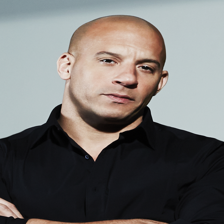

In [5]:
image1.resize((224,224))

In [42]:
image2=Image.open("main-qimg-79f23e6c960afe2b386d2a40f910de5d.webp")

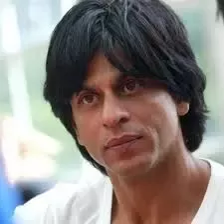

In [43]:
image2.resize((224,224))

In [9]:
img1 = tf.image.resize(image1, (224, 224))  # Resizes to (224, 224)

In [10]:
img1 = np.expand_dims(img1, axis=0)

In [11]:
np.argmax(model.predict(img1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step


2

In [56]:
img2=tf.image.resize(image2,(224,224))

In [57]:
img2=np.expand_dims(img2,axis=0)

In [58]:
img2=img2/255

In [60]:
np.argmax(model.predict(img2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


0

In [69]:
image3=Image.open("/Users/ashish/Desktop/final_projects/hairloss/l-intro-1698964315.jpg")

In [70]:
image3=tf.image.resize(image3,(224,224))

In [71]:
image3=np.expand_dims(image3,axis=0)

In [72]:
image3=image3/255

In [73]:
np.argmax(model.predict(image3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


2